In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mygene import MyGeneInfo
import scipy.stats as stats
from statannotations.Annotator import Annotator
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


Analysis based on the Vaughan-Jackson A, Stodolak S, Ebrahimi KH, Johnson E, Reardon PK, Dupont M, et al. Density dependent regulation of inflammatory responses in macrophages. Front Immunol. 2022;13:895488. Epub 20221216. doi: 10.3389/fimmu.2022.895488. PubMed PMID: 36591218; PubMed Central PMCID: PMCPMC9800520.

To determine whether macrophage density influences expression of the CD36- and IL1B-associated transcriptional programmes identified in our single-cell analyses, we reanalyzed the published macrophage density RNA-seq dataset from Vaughan-Jackson et al. (2022). Gene-level TPM values were extracted for representative genes associated with the CD36 programme (CD36, CTSK, GPNMB, HMOX1, IGF1, and METRNL) and the IL1B programme (IL1B, ACOD1, TNF, NLRP3, CXCL2, and NFKBIA). Samples were grouped according to the original low-, medium-, and high-density culture conditions. For each gene, expression levels across biological replicates were visualized as individual data points, and mean expression was calculated for each density condition to assess density-dependent trends. 

In [2]:
import os
import pandas as pd
from mygene import MyGeneInfo

# =========================================================
# 1. Set folder to current working directory
# =========================================================
base_dir = "."   # current folder

# =========================================================
# 2. Find quant.sf files
# =========================================================
files = [f for f in os.listdir(base_dir) if f.endswith("_quant.sf")]
print("Found files:", files)

# =========================================================
# 3. Load each file, label sample and density, apply TPM filter
# =========================================================
all_data = []

for f in files:
    sample = f.replace("_quant.sf", "")      # e.g. Low_1
    density = sample.split("_")[0]           # Low / Mid / High
    path = os.path.join(base_dir, f)

    df = pd.read_csv(path, sep="\t")
    df = df[df["TPM"] > 0.5].copy()

    df["Sample"] = sample
    df["Density"] = density

    all_data.append(df[["Name", "TPM", "Sample", "Density"]])

df_all = pd.concat(all_data, ignore_index=True)
print("Combined filtered dataset shape:", df_all.shape)

# =========================================================
# 4. Clean transcript IDs
# =========================================================
df_all["Name"] = df_all["Name"].astype(str).str.split(".").str[0]

# =========================================================
# 5. Map transcript IDs to gene symbols
# =========================================================
transcripts = df_all["Name"].unique().tolist()

mg = MyGeneInfo()
results = mg.querymany(
    transcripts,
    scopes="ensembl.transcript",
    fields="symbol",
    species="human"
)

mapping = pd.DataFrame([
    {"Name": r["query"], "Gene": r["symbol"]}
    for r in results
    if not r.get("notfound") and "symbol" in r
])

print("Mapped transcripts:", mapping.shape[0])

# =========================================================
# 6. Merge and collapse transcript TPM to gene TPM
# =========================================================
df_merged = df_all.merge(mapping, on="Name", how="inner")

df_gene = (
    df_merged
    .groupby(["Gene", "Sample", "Density"], as_index=False)["TPM"]
    .sum()
)

print("df_gene shape:", df_gene.shape)
print(df_gene.head())

# =========================================================
# 7. Save
# =========================================================
df_gene.to_pickle("df_gene.pkl")
df_gene.to_csv("df_gene.csv", index=False)

Found files: ['High_1_quant.sf', 'High_2_quant.sf', 'High_3_quant.sf', 'Low_1_quant.sf', 'Low_2_quant.sf', 'Low_3_quant.sf', 'Mid_1_quant.sf', 'Mid_2_quant.sf', 'Mid_3_quant.sf']
Combined filtered dataset shape: (440795, 4)


18 input query terms found dup hits:	[('ENST00000639481', 2), ('ENST00000640476', 2), ('ENST00000639594', 2), ('ENST00000639456', 2), ('E
1232 input query terms found no hit:	['ENST00000622660', 'ENST00000660930', 'ENST00000355439', 'ENST00000643905', 'ENST00000545482', 'ENS


Mapped transcripts: 76704
df_gene shape: (117725, 4)
   Gene  Sample Density        TPM
0  A1BG  High_1    High  37.179927
1  A1BG  High_2    High  38.294205
2  A1BG  High_3    High  40.710410
3  A1BG   Low_1     Low  29.024805
4  A1BG   Low_2     Low  34.636773


       Gene  Sample Density          TPM
14678  CD36   Low_1     Low   229.465163
14679  CD36   Low_2     Low   162.850603
14680  CD36   Low_3     Low   234.943550
14681  CD36   Mid_1     Mid   232.204876
14682  CD36   Mid_2     Mid   152.948240
14683  CD36   Mid_3     Mid   329.215256
14675  CD36  High_1    High   479.770159
14676  CD36  High_2    High   410.965137
14677  CD36  High_3    High   592.021666
42932  IL1B   Low_1     Low   926.045887
42933  IL1B   Low_2     Low  1118.767312
42934  IL1B   Low_3     Low   674.442319
42935  IL1B   Mid_1     Mid   260.127882
42936  IL1B   Mid_2     Mid   686.428660
42937  IL1B   Mid_3     Mid   251.005943
42929  IL1B  High_1    High    14.800847
42930  IL1B  High_2    High    16.571918
42931  IL1B  High_3    High    14.127456


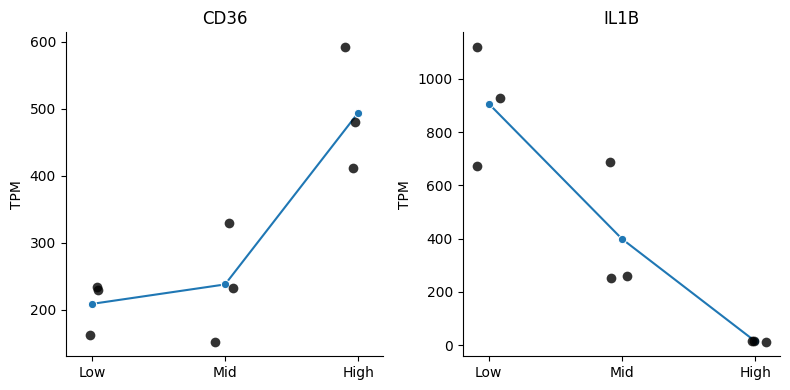

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# subset genes of interest
genes_of_interest = ["CD36", "IL1B"]
df_plot = df_gene[df_gene["Gene"].isin(genes_of_interest)].copy()

# enforce density order
density_order = ["Low", "Mid", "High"]
df_plot["Density"] = pd.Categorical(df_plot["Density"], categories=density_order, ordered=True)

print(df_plot.sort_values(["Gene", "Density", "Sample"]))

# plot
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True)

for ax, gene in zip(axes, genes_of_interest):
    sub = df_plot[df_plot["Gene"] == gene].copy()

    # mean trend
    #mean_df = sub.groupby("Density", as_index=False)["TPM"].mean()
    mean_df = sub.groupby("Density", as_index=False, observed=False)["TPM"].mean()


    sns.stripplot(
        data=sub,
        x="Density",
        y="TPM",
        order=density_order,
        color="black",
        size=7,
        alpha=0.8,
        ax=ax
    )

    sns.lineplot(
        data=mean_df,
        x="Density",
        y="TPM",
        sort=False,
        marker="o",
        linewidth=1.5,
        color="tab:blue",
        ax=ax
    )

    ax.set_title(gene)
    ax.set_xlabel("")
    ax.set_ylabel("TPM")
    ax.grid(False)

sns.despine()
plt.tight_layout()
plt.show()

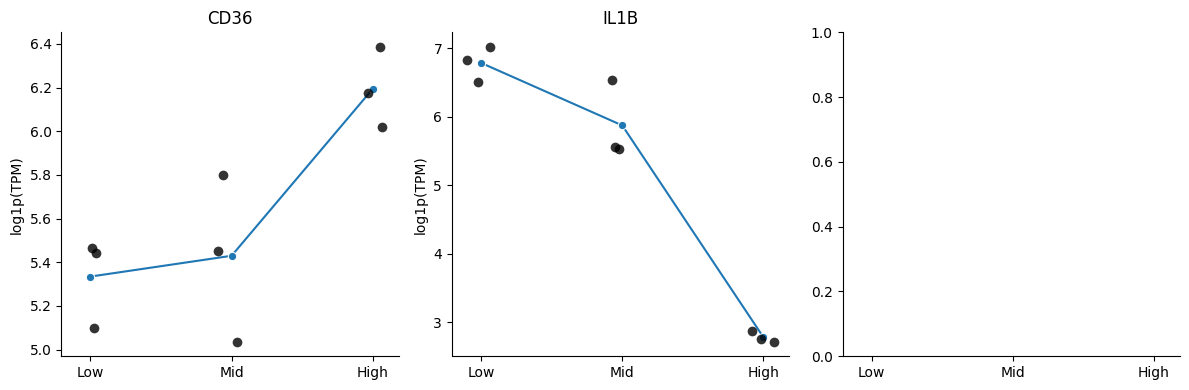

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# genes
genes_of_interest = ["CD36", "IL1B"]

# subset
df_plot = df_gene[df_gene["Gene"].isin(genes_of_interest)].copy()

# enforce density order
density_order = ["Low", "Mid", "High"]
df_plot["Density"] = pd.Categorical(df_plot["Density"], categories=density_order, ordered=True)

# log transform
df_plot["TPM_log"] = np.log1p(df_plot["TPM"])

# plot
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharex=True)

for ax, gene in zip(axes, genes_of_interest):
    sub = df_plot[df_plot["Gene"] == gene].copy()

    # mean trend
    mean_df = sub.groupby("Density", as_index=False,observed=True)["TPM_log"].mean()

    sns.stripplot(
        data=sub,
        x="Density",
        y="TPM_log",
        order=density_order,
        color="black",
        size=7,
        alpha=0.8,
        ax=ax
    )

    sns.lineplot(
        data=mean_df,
        x="Density",
        y="TPM_log",
        marker="o",
        linewidth=1.5,
        color="tab:blue",
        ax=ax
    )

    ax.set_title(gene)
    ax.set_xlabel("")
    ax.set_ylabel("log1p(TPM)")
    ax.grid(False)

sns.despine()
plt.tight_layout()
plt.show()

Analysis of NMF-programme genes

Present genes: ['CD36', 'CTSK', 'CXCL2', 'GPNMB', 'HMOX1', 'IGF1', 'IL1B', 'METRNL', 'NFKBIA', 'NLRP3', 'TNF']
Missing genes: ['ACOD1']


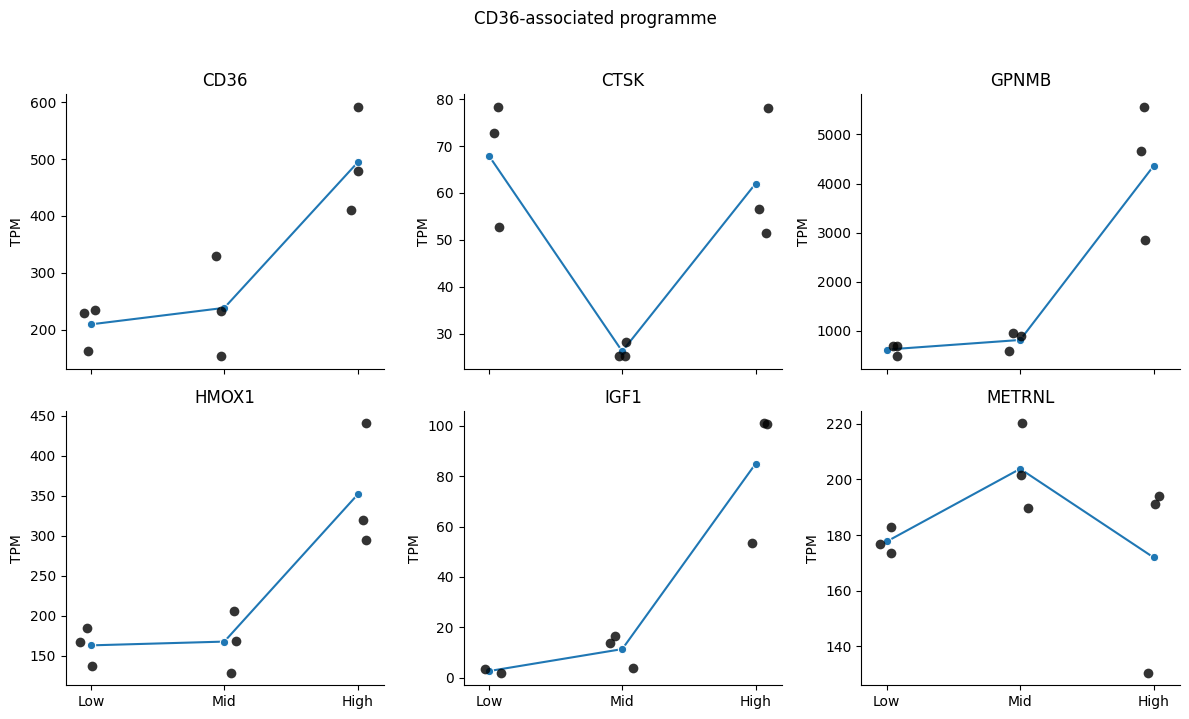

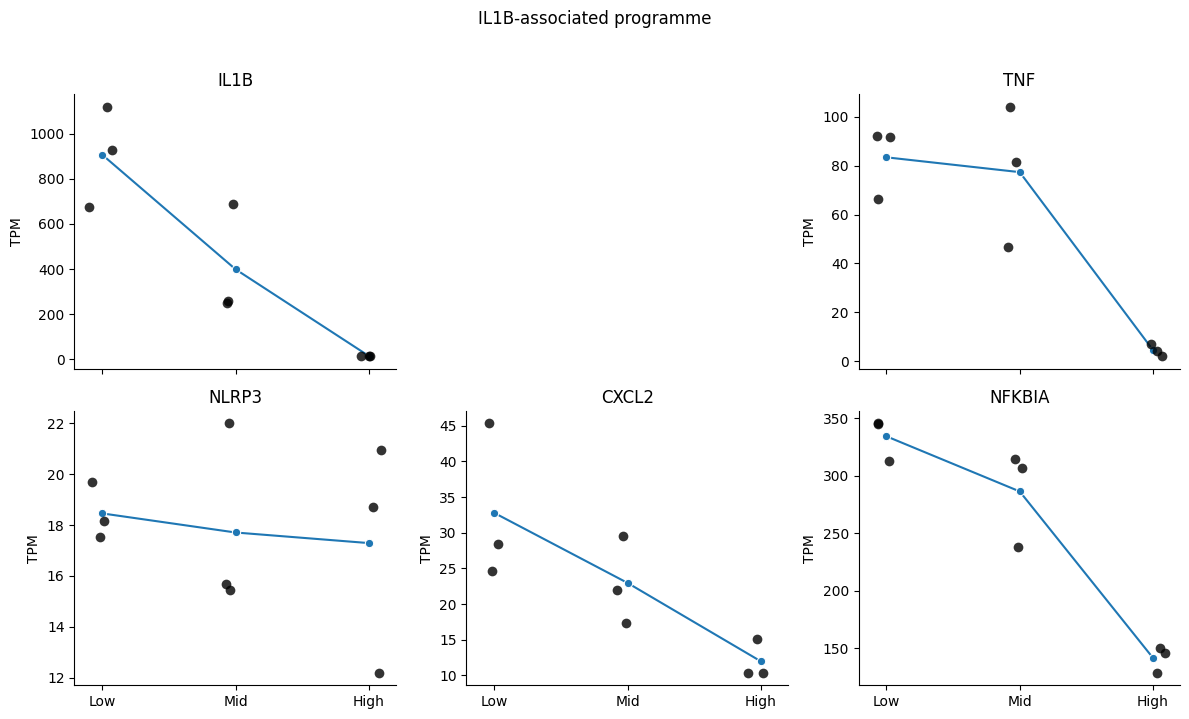

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# gene sets
# ---------------------------------------------------------
cd36_programme = ["CD36", "CTSK", "GPNMB", "HMOX1", "IGF1", "METRNL"]
il1b_programme = ["IL1B", "ACOD1", "TNF", "NLRP3", "CXCL2", "NFKBIA"]

genes_of_interest = cd36_programme + il1b_programme
density_order = ["Low", "Mid", "High"]

# ---------------------------------------------------------
# subset data
# ---------------------------------------------------------
df_plot = df_gene[df_gene["Gene"].isin(genes_of_interest)].copy()
df_plot["Density"] = pd.Categorical(df_plot["Density"], categories=density_order, ordered=True)

# optional: check which genes are present
present_genes = sorted(df_plot["Gene"].unique())
missing_genes = sorted(set(genes_of_interest) - set(present_genes))
print("Present genes:", present_genes)
print("Missing genes:", missing_genes)

# ---------------------------------------------------------
# plotting helper
# ---------------------------------------------------------
def plot_gene_panel(df_sub, gene_list, title, ycol="TPM"):
    n = len(gene_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for ax, gene in zip(axes, gene_list):
        sub = df_sub[df_sub["Gene"] == gene].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        mean_df = sub.groupby("Density", as_index=False, observed=True)[ycol].mean()

        sns.stripplot(
            data=sub,
            x="Density",
            y=ycol,
            order=density_order,
            color="black",
            size=7,
            alpha=0.8,
            ax=ax
        )

        sns.lineplot(
            data=mean_df,
            x="Density",
            y=ycol,
            sort=False,
            marker="o",
            linewidth=1.5,
            color="tab:blue",
            ax=ax
        )

        ax.set_title(gene)
        ax.set_xlabel("")
        ax.set_ylabel(ycol)
        ax.grid(False)

    # hide unused axes
    for ax in axes[len(gene_list):]:
        ax.set_visible(False)

    fig.suptitle(title, y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# raw TPM plots
# ---------------------------------------------------------
plot_gene_panel(df_plot, cd36_programme, "CD36-associated programme", ycol="TPM")
plot_gene_panel(df_plot, il1b_programme, "IL1B-associated programme", ycol="TPM")